In [2]:
## IBL initiations

from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell

In [3]:
merge_probes?

Signature: merge_probes(spikes_list, clusters_list)
Docstring:
Merge spikes and clusters information from several probes as if they were recorded from the same probe.
This can be used to account for the fact that data from the probes recorded in the same session are not
statistically independent as they have the same underlying behaviour.

NOTE: The clusters dataframe will be re-indexed to avoid duplicated indices. Accordingly, spikes['clusters']
will be updated. To unambiguously identify clusters use the column 'uuids'

Parameters
----------
spikes_list: list of dicts
    List of spike dictionaries as loaded by SpikeSortingLoader or brainwidemap.load_good_units
clusters_list: list of pandas.DataFrames
    List of cluster dataframes as loaded by SpikeSortingLoader.merge_clusters or brainwidemap.load_good_units

Returns
-------
merged_spikes: dict
    Merged and time-sorted spikes in single dictionary, where 'clusters' is adjusted to index into merged_clusters
merged_clusters: pandas.Da

In [138]:
## Standard python imports and IDTxL

import numpy as np
from idtxl.active_information_storage import ActiveInformationStorage
from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.multivariate_pid import MultivariatePID
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
import itertools

In [139]:
## setup one and bwm

one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
bwm_df = bwm_query()

# use frozen bwm data

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [140]:
bwm_df.head()

,pid,eid,probe_name,session_number,date,subject,lab
0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,probe00,1,2020-02-18,NYU-11,angelakilab
1,47be9ae4-290f-46ab-b047-952bc3a1a509,56956777-dca5-468c-87cb-78150432cc57,probe01,1,2020-02-21,NYU-11,angelakilab
2,6be21156-33b0-4f70-9a0f-65b3e3cd6d4a,56956777-dca5-468c-87cb-78150432cc57,probe00,1,2020-02-21,NYU-11,angelakilab
3,8dfb86c8-d45c-46c4-90ec-33078014d434,4364a246-f8d7-4ce7-ba23-a098104b96e4,probe01,1,2020-01-20,NYU-12,angelakilab
4,c893c0a3-5597-49cf-baa1-60efdfdef542,b182b754-3c3e-4942-8144-6ee790926b58,probe01,1,2020-01-21,NYU-12,angelakilab


In [141]:
# use these two insertions for our analysis,
# this is the chosen animal
bwm_df.iloc[9], bwm_df.iloc[10]

(pid               8895f61f-1c17-4d2f-8b9b-77476c5261b6
 eid               8c33abef-3d3e-4d42-9f27-445e9def08f9
 probe_name                                     probe01
 session_number                                       2
 date                                        2020-08-13
 subject                                         NYU-21
 lab                                        angelakilab
 Name: 9, dtype: object,
 pid               f475ae14-9415-453e-b800-1480ea1c868d
 eid               8c33abef-3d3e-4d42-9f27-445e9def08f9
 probe_name                                     probe00
 session_number                                       2
 date                                        2020-08-13
 subject                                         NYU-21
 lab                                        angelakilab
 Name: 10, dtype: object)

In [142]:
def download_data(one, bwm_df, idx):
    pid = bwm_df.pid[idx]
    spikes, clusters = load_good_units(one, pid, compute_metrics=False)
    return spikes, clusters

In [7]:
# spikes_insertion_one, clusters_insertion_one = download_data(one, bwm_df, 9)
# eid = bwm_df.eid[9]
# trials, mask = load_trials_and_mask(one, eid, min_rt=0.08, max_rt=2.0, nan_exclude="default")


# # spikes_insertion_two, clusters_insertion_two = download_data(one, bwm_df, 10)

In [8]:
# # use trials[mask] to get trials with minimum reaction time of 008, maximum reaction time of 2 and excluding nans
# trials[mask]

In [9]:
# ## now what!
# ## segment into spikes for conditions

# # for spike counts, i.e, for decoding like analysis
# # define event window and segment

# correct_trials = trials[mask][trials[mask]["feedbackType"] == 1]
# visible_trials_left = correct_trials.contrastLeft.isin([1, 0.25, 0.125, 0.0625])
# visible_trials_right = correct_trials.contrastRight.isin([1, 0.25, 0.125, 0.0625])
# visible_trials = visible_trials_left | visible_trials_right


# time_window = [0.0, 0.1]
# events = correct_trials.stimOn_times
# events_tw = np.array([events + time_window[0], events + time_window[1]]).T

In [10]:
# # spike_count = neurons x events, cluster_id = neurons
# # this is an aggregate for each neuron, to be used for the de
# spike_count, cluster_id = get_spike_counts_in_bins(
#     spikes_insertion_one["times"], spikes_insertion_one["clusters"], events_tw
# )

# # also, now for single cells, to be used for a lag based analysis
# peths, bin_counts = singlecell.calculate_peths(
#     spikes_insertion_one["times"],
#     spikes_insertion_one["clusters"],
#     cluster_id,
#     align_times=events,
#     smoothing=False,
#     bin_size=0.01,
#     pre_time=0.1,
#     post_time=0,
# )

# # get clusters
# clusters_insertion_one.acronym[cluster_id].unique()

In [143]:
## how to make aggregate regions?


def aggregate_regions(binned_spike_counts, acronyms):
    # binned_spike_counts = trials x neurons x timepoints
    regions = np.unique(acronyms)
    data = np.zeros(
        (binned_spike_counts.shape[0], len(regions), binned_spike_counts.shape[-1])
    )  # trials, regions, timepoints
    for idx, r in enumerate(regions):
        neurons = np.argwhere(acronyms == r).reshape(
            -1,
        )
        aggregate_cluster = np.sum(binned_spike_counts[:, neurons, :], axis=1)
        data[:, idx, :] = aggregate_cluster
    return data, regions

In [144]:
# aggregated, regions = aggregate_regions(
#     bin_counts, clusters_insertion_one.acronym[cluster_id].values
# )

In [145]:
# regions = clusters_insertion_one.acronym[cluster_id].unique()
# regions

In [146]:
# regions

In [147]:
# now I have aggregate regions, counts in seconds as well as raw counts for each neuron in a time bin

# get visible trials

In [148]:
# # partial information decomposition for 2

# left_spike_data = np.asarray(bin_counts[visible_trials_left, :, :], dtype=np.int32)
# right_spike_data = np.asarray(bin_counts[visible_trials_right, :, :], dtype=np.int32)

# spike_count_data = spike_count[:, visible_trials]
# stim_side = visible_trials_left * 1 + visible_trials_right * -1

# # remove zeros
# stim_side = stim_side[stim_side != 0].values

In [149]:
# PID decomposition and group by region
# just for expidency, find neurons that are nice


def find_important_neurons(data):
    mean_spike_rate = np.mean(data, axis=(1, 0))
    important_neurons = np.mean(data, axis=1) > mean_spike_rate
    return np.argwhere(important_neurons == True).reshape(
        -1,
    )

In [150]:
# important_neurons = find_important_neurons(spike_count_data)

In [151]:
# left_spike_data.shape
# trials x neurons x timepoints

In [152]:
# data_left = Data(left_spike_data[:, important_neurons, :], dim_order="rps", normalise=False)
# data_right = Data(right_spike_data[:, important_neurons, :], dim_order="rps", normalise=False)

In [153]:
# now run PID with each neuron as source and others as target
def generate_sources(neurons):
    global_sources = []
    for idx in range(len(neurons)):
        mask = np.ones(neurons.shape, bool)
        mask[idx] = False
        sources = []
        for combinations in itertools.combinations(neurons[mask], 2):
            sources.append(combinations)
        global_sources.append(sources)
    return np.asarray(global_sources)

In [22]:
# sources = generate_sources(np.arange(len(important_neurons)))
# targets = np.arange(len(important_neurons), dtype=np.int32)

In [154]:
from idtxl.bivariate_pid import BivariatePID


In [23]:
def computePID(sources, targets, data):
    PID_storage = np.zeros((len(targets), len(sources[0]), 4))
    for index, target in tqdm(enumerate(targets)):
        pid_info = []
        target = int(target)
        for r in tqdm(range(len(sources[index])), leave=False):
            S = sources[index][r]
            partial_decomposition = MultivariatePID()
            settings_SxPID = {"pid_estimator": "SxPID", "lags_pid": [2, 2]}
            result = partial_decomposition.analyse_single_target(
                data=data, settings=settings_SxPID, target=target, sources=S
            )
            pid_info.append(
                [
                    result.get_single_target(target)["avg"][(1,),][2],
                    result.get_single_target(target)["avg"][(2,),][2],
                    result.get_single_target(target)["avg"][
                        (1,),
                        (2,),
                    ][2],
                    result.get_single_target(target)["avg"][
                        (
                            1,
                            2,
                        ),
                    ][2],
                ]
            )
        pid_info = np.asarray(pid_info)
        PID_storage[index, :, :] = pid_info
    return PID_storage

In [160]:
def computePID_bivariate(sources, targets, data):

    PID_storage = np.zeros((len(targets), len(sources[0]), 4))
    for index, target in tqdm(enumerate(targets)):
        pid_info = []
        target = int(target)
        for r in tqdm(range(len(sources[index])), leave=False):
            S = sources[index][r]
            partial_decomposition = MultivariatePID()
            settings_tartu = {'pid_estimator': 'TartuPID', 'lags_pid': [2, 2]}
            result = partial_decomposition.analyse_single_target(
                data=data, settings=settings_tartu, target=target, sources=S
            )
            pid_info.append(
                [
                    result.get_single_target(target)['unq_s1'],
                    result.get_single_target(target)['unq_s2'],
                    result.get_single_target(target)['shd_s1_s2'],
                    result.get_single_target(target)['syn_s1_s2'],
                ]
            )
        pid_info = np.asarray(pid_info)
        PID_storage[index, :, :] = pid_info
    return PID_storage


In [24]:
# # get the litany of regions
# neuron_location = clusters_insertion_one["acronym"][important_neurons].values

In [25]:
# neuron_location = clusters_insertion_one["acronym"][important_neurons].values
# regions = np.unique(neuron_location)

In [156]:
def generate_groupings(neuron_location, neurons):
    targets = np.arange(len(neurons), dtype=np.int32)
    sources = generate_sources(targets)

    # now for each target, we will have the source grouping
    # source_grouping = np.empty_like(sources)
    in_out_grouping_logic = np.zeros((sources.shape[0], sources.shape[1]))
    for t in range(sources.shape[0]):
        # for each target region
        target_neuron = neuron_location[t]
        for s in range(sources.shape[1]):
            n1 = sources[t][s][0]
            n2 = sources[t][s][1]
            source_neuron_1 = neuron_location[n1]
            source_neuron_2 = neuron_location[n2]
            # source_grouping[t,s,0] = neuron_location[n1]
            # source_grouping[t,s,1] = neuron_location[n2]
            # 1 is same region, 2 is one from same region and another from another, 3 is all from another region
            # we can make this more fine tuned, however combinatorial explosion imminent
            # how to deal with this?
            # targeted hypothesis makes more sense
            if source_neuron_1 == target_neuron and source_neuron_2 == target_neuron:
                # this means everything is in one region
                in_out_grouping_logic[t, s] = 1
            elif (source_neuron_1 == target_neuron and source_neuron_2 != target_neuron) or (
                source_neuron_1 != target_neuron and source_neuron_2 == target_neuron
            ):
                in_out_grouping_logic[t, s] = 2
            else:
                in_out_grouping_logic[t, s] = 3
    return in_out_grouping_logic

In [27]:
# G = generate_groupings(neuron_location, important_neurons)
# pid_storage_left = computePID(sources, targets, data=data_left)

In [28]:
# now for spike counts and choices
# distribution : left/right, neuron1, neuron2

In [29]:
# spike_count_data_important = spike_count_data[important_neurons, :]

In [157]:
def build_decoding_array(target_variable_array, source_variable_array):
    decoding_array = []
    for neuron1 in range(source_variable_array.shape[0]):
        spikes1 = source_variable_array[neuron1, :]
        for neuron2 in range(neuron1, source_variable_array.shape[0]):
            if neuron1 == neuron2:
                continue
            spikes2 = source_variable_array[neuron2, :]
            data = np.vstack([target_variable_array, spikes1, spikes2])
            decoding_array.append(data)
    decoding_array = np.asarray(decoding_array)
    return decoding_array

In [158]:
def generate_groupings_decoding(neuron_location, neurons):
    groupings = []
    regions = []

    for n1 in range(len(neurons)):
        n1_region = neuron_location[n1]

        for n2 in range(n1, len(neurons)):

            if n1 == n2:

                continue

            n2_region = neuron_location[n2]
            if n1_region == n2_region:
                groupings.append(1)
            else:
                groupings.append(0)
            regions.append([n1_region, n2_region])
    return np.asarray(groupings), np.asarray(regions)

In [159]:
# decoding_array = build_decoding_array(stim_side, spike_count_data_important)
# # transpose so that it is neurons x trials x spike_counts
# # multivariate cause why not
# # target is variable 0
# decoding_array = np.transpose(decoding_array, (0, 2, 1))

In [33]:
def compute_pid_neurons(data):

    neuron_combinations = data.shape[0]
    PID_storage = np.zeros((neuron_combinations, 4))
    for idx in tqdm(range(neuron_combinations)):
        z = data[idx, :, 0]
        x1 = data[idx, :, 1]
        x2 = data[idx, :, 2]
        subset_data = Data(np.vstack([x1, x2, z]), "ps", normalise=False)
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid": [0, 0]}

        target = int(2)
        sources = [0, 1]
        partial_decomposition = MultivariatePID()
        result = partial_decomposition.analyse_single_target(
            data=subset_data, settings=settings_SxPID, target=target, sources=sources
        )
        pid_info = [
            result.get_single_target(target)["avg"][(1,),][2],
            result.get_single_target(target)["avg"][(2,),][2],
            result.get_single_target(target)["avg"][
                (1,),
                (2,),
            ][2],
            result.get_single_target(target)["avg"][
                (
                    1,
                    2,
                ),
            ][2],
        ]
        pid_info = np.asarray(pid_info)
        PID_storage[idx, :] = pid_info
    return PID_storage

In [161]:
def compute_pid_neurons_bivariate(data):

    neuron_combinations = data.shape[0]
    PID_storage = np.zeros((neuron_combinations, 4))
    for idx in tqdm(range(neuron_combinations)):
        z = data[idx, :, 0]
        x1 = data[idx, :, 1]
        x2 = data[idx, :, 2]
        subset_data = Data(np.vstack([x1, x2, z]), "ps", normalise=False)
        settings_tartu = {'pid_estimator': 'TartuPID', 'lags_pid': [0, 0]}

        target = int(2)
        sources = [0, 1]
        partial_decomposition = BivariatePID()
        result = partial_decomposition.analyse_single_target(
            data=subset_data, settings=settings_tartu, target=target, sources=sources
        )
        pid_info = [
            result.get_single_target(target)['unq_s1'],
            result.get_single_target(target)['unq_s2'],
            result.get_single_target(target)['shd_s1_s2'],
            result.get_single_target(target)['syn_s1_s2'],
        ]
        pid_info = np.asarray(pid_info)
        PID_storage[idx, :] = pid_info
    return PID_storage

In [34]:
# PID_decoding = compute_pid_neurons(decoding_array)

In [35]:
# PID_decoding.shape

In [36]:
# _, Rdecoding = generate_groupings_decoding(neuron_location, important_neurons)

In [37]:
# get unique regions
# iterate over inside vs outside

In [162]:
# how to group these regions


def group_decoding_results(PID_decoding, Rdecoding, regions):

    unique_regions = np.unique(regions)
    inregion_pid = np.zeros((len(unique_regions), 4))
    inregion_count = np.zeros((len(unique_regions)))
    outregion_pid = np.zeros((len(unique_regions), 4))
    outregion_count = np.zeros((len(unique_regions)))

    inregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    outregion_std_calculator = [[] * i for i in range(len(unique_regions))]

    for region_id, region in enumerate(unique_regions):

        # in group
        for idx in range(Rdecoding.shape[0]):  # iterate over all possibilites
            r1 = Rdecoding[idx, 0]
            r2 = Rdecoding[idx, 1]

            if r1 == region and r2 == region:
                inregion_pid[region_id] = inregion_pid[region_id] + PID_decoding[idx, :]
                inregion_count[region_id] += 1
                inregion_std_calculator[region_id].append(PID_decoding[idx, :])
            else:
                outregion_pid[region_id] = outregion_pid[region_id] + PID_decoding[idx, :]
                outregion_count[region_id] += 1
                outregion_std_calculator[region_id].append(PID_decoding[idx, :])

    # just compute the std
    inregion_std = np.zeros((len(unique_regions), 4))
    outregion_std = np.zeros((len(unique_regions), 4))
    for idx, x in enumerate(inregion_std_calculator):
        inregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(outregion_std_calculator):
        outregion_std[idx, :] = np.nanstd(x, axis=0)

    return (
        inregion_pid,
        inregion_count,
        outregion_pid,
        outregion_count,
        inregion_std,
        outregion_std,
    )

In [39]:
# # inregion_pid, inregion_count, outregion_pid, outregion_count, inregion_std, outregion_std = (
#     group_decoding_results(PID_decoding, Rdecoding, neuron_location)
# )

In [163]:
def combine_multidimensional_pid(pid_storage_condition, groupings, neuron_location):

    unique_regions = np.unique(neuron_location)
    inregion_pid = np.zeros((len(unique_regions), 4))
    inregion_count = np.zeros((len(unique_regions)))
    outregion_pid = np.zeros((len(unique_regions), 4))
    outregion_count = np.zeros((len(unique_regions)))
    mixedregion_pid = np.zeros((len(unique_regions), 4))
    mixedregion_count = np.zeros((len(unique_regions)))

    # similar stuff
    # 1 is same region, 2 is one from same region and another from another, 3 is all from another region
    inregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    outregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    mixedregion_std_calculator = [[] * i for i in range(len(unique_regions))]

    for idx, region_name in enumerate(neuron_location):
        location = np.argwhere(region_name == unique_regions)

        inregions = np.argwhere(groupings[idx] == 1).reshape(
            -1,
        )
        mixedregions = np.argwhere(groupings[idx] == 2).reshape(
            -1,
        )
        outregions = np.argwhere(groupings[idx] == 3).reshape(
            -1,
        )

        # compute means for region
        inregion_pid_single_neuron = pid_storage_condition[idx, inregions, :]
        inregion_mean = np.nanmean(inregion_pid_single_neuron, axis=0)

        mixedregion_pid_single_neuron = pid_storage_condition[idx, mixedregions, :]
        mixedregion_mean = np.nanmean(mixedregion_pid_single_neuron, axis=0)

        outregion_pid_single_neuron = pid_storage_condition[idx, outregions, :]
        outregion_mean = np.nanmean(outregion_pid_single_neuron, axis=0)

        # 3 means for each neuron, now assign to global
        inregion_pid[location, :] = inregion_pid[location, :] + inregion_mean
        inregion_count[location] += 1
        inregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(inregion_mean)

        mixedregion_pid[location, :] = mixedregion_pid[location, :] + mixedregion_mean
        mixedregion_count[location] += 1
        mixedregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(mixedregion_mean)

        outregion_pid[location, :] = outregion_pid[location, :] + outregion_mean
        outregion_count[location] += 1
        outregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(outregion_mean)

    # do something similar
    inregion_std = np.zeros((len(unique_regions), 4))
    outregion_std = np.zeros((len(unique_regions), 4))
    mixedregion_std = np.zeros((len(unique_regions), 4))

    for idx, x in enumerate(inregion_std_calculator):
        inregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(outregion_std_calculator):
        outregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(mixedregion_std_calculator):
        mixedregion_std[idx, :] = np.nanstd(x, axis=0)

    return (
        inregion_pid,
        inregion_count,
        inregion_std,
        outregion_pid,
        outregion_count,
        outregion_std,
        mixedregion_pid,
        mixedregion_count,
        mixedregion_std,
    )

In [41]:
# (
#     inregion_pid,
#     inregion_count,
#     inregion_std,
#     outregion_pid,
#     outregion_count,
#     outregion_std,
#     mixedregion_pid,
#     mixedregion_count,
#     mixedregion_std,
# ) = combine_multidimensional_pid(pid_storage_left, G, neuron_location)

In [164]:
# have everything, now compute :D
spikes_insertion_one, clusters_insertion_one = download_data(one, bwm_df, 9)
eid = bwm_df.eid[9]
trials, mask = load_trials_and_mask(one, eid, min_rt=0.08, max_rt=2.0, nan_exclude="default")

In [165]:
# spikes_insertion_two, clusters_insertion_two = download_data(one, bwm_df, 10)

# ----------------------------STIMONSET---------------------------------#
correct_trials = trials[mask][trials[mask]["feedbackType"] == 1]
visible_trials_left = correct_trials.contrastLeft.isin([1, 0.25, 0.125, 0.0625])
visible_trials_right = correct_trials.contrastRight.isin([1, 0.25, 0.125, 0.0625])
visible_trials = visible_trials_left | visible_trials_right


time_window_stim = [0.0, 0.1]
events_stim = correct_trials.stimOn_times
events_stim_tw = np.array([events_stim + time_window_stim[0], events_stim + time_window_stim[1]]).T

## for left and right sided visible stimulus, only correct trials

spike_count_stim, cluster_id = get_spike_counts_in_bins(
    spikes_insertion_one["times"], spikes_insertion_one["clusters"], events_stim_tw
)

# also, now for single cells, to be used for a lag based analysis
p_eths, bin_counts_stim = singlecell.calculate_peths(
    spikes_insertion_one["times"],
    spikes_insertion_one["clusters"],
    cluster_id,
    align_times=events_stim,
    smoothing=False,
    bin_size=0.01,
    pre_time=0.0,
    post_time=0.1,
)


left_stim_spike_data = np.asarray(bin_counts_stim[visible_trials_left, :, :], dtype=np.int32)
right_stim_spike_data = np.asarray(bin_counts_stim[visible_trials_right, :, :], dtype=np.int32)

spike_count_stim_data = spike_count_stim[:, visible_trials]
stim_side = visible_trials_left * 1 + visible_trials_right * -1

# remove zeros
stim_side = stim_side[stim_side != 0].values

important_neurons_stim = find_important_neurons(spike_count_stim_data)

# data for single cell analysis
data_left_stim = Data(
    left_stim_spike_data[:, important_neurons_stim, :], dim_order="rps", normalise=False
)
data_right_stim = Data(
    right_stim_spike_data[:, important_neurons_stim, :], dim_order="rps", normalise=False
)
sources_stim = generate_sources(np.arange(len(important_neurons_stim)))
targets_stim = np.arange(len(important_neurons_stim), dtype=np.int32)

neuron_location_stim = clusters_insertion_one["acronym"][important_neurons_stim].values
# regions = np.unique(neuron_location_stim)


groupings_singlecell_stim = generate_groupings(neuron_location_stim, important_neurons_stim)
pid_storage_left_stim = computePID_bivariate(sources_stim, targets_stim, data=data_left_stim)
pid_storage_right_stim = computePID_bivariate(sources_stim, targets_stim, data=data_right_stim)


spike_count_stim_data_important = spike_count_stim_data[important_neurons_stim, :]
decoding_array_stim = build_decoding_array(stim_side, spike_count_stim_data_important)

# transpose so that it is neurons x trials x spike_counts
# multivariate cause why not
# target is variable 0
decoding_array_stim = np.transpose(decoding_array_stim, (0, 2, 1))

PID_stim_decoding = compute_pid_neurons_bivariate(decoding_array_stim)

_, Rdecoding_stim = generate_groupings_decoding(neuron_location_stim, important_neurons_stim)

(
    inregion_pid_stim_decoding,
    inregion_count_stim_decoding,
    outregion_pid_stim_decoding,
    outregion_count_stim_decoding,
    inregion_std_stim_decoding,
    outregion_std_stim_decoding,
) = group_decoding_results(PID_stim_decoding, Rdecoding_stim, neuron_location_stim)


(
    inregion_pid_stim_left,
    inregion_count_stim_left,
    inregion_std_stim_left,
    outregion_pid_stim_left,
    outregion_count_stim_left,
    outregion_std_stim_left,
    mixedregion_pid_stim_left,
    mixedregion_count_stim_left,
    mixedregion_std_stim_left,
) = combine_multidimensional_pid(
    pid_storage_left_stim, groupings_singlecell_stim, neuron_location_stim
)


(
    inregion_pid_stim_right,
    inregion_count_stim_right,
    inregion_std_stim_right,
    outregion_pid_stim_right,
    outregion_count_stim_right,
    outregion_std_stim_right,
    mixedregion_pid_stim_right,
    mixedregion_count_stim_right,
    mixedregion_std_stim_right,
) = combine_multidimensional_pid(
    pid_storage_right_stim, groupings_singlecell_stim, neuron_location_stim
)

Adding data with properties: 23 processes, 10 samples, 130 replications
overwriting existing data
Adding data with properties: 23 processes, 10 samples, 210 replications
overwriting existing data


0it [00:00, ?it/s]

  0%|          | 0/231 [00:00<?, ?it/s]

PyOpenCl is not available on this system. Install it using pip or the package manager to use OpenCL-powered CMI estimation.



  File "d:\personal\phd\code\idtxl\idtxl\estimators_opencl.py", line 9, in <module>
    import pyopencl as cl
d:\personal\phd\code\idtxl\idtxl\data.py:273: RuntimeWarning: invalid value encountered in cast
  realisations = np.empty((n_real_time * n_real_repl, len(idx_list))).astype(


TypeError: TartuPID.estimate() got an unexpected keyword argument 's'

In [ ]:
# choice window

left_choice = trials[mask].choice == 1
right_choice = trials[mask].choice == -1
choice_trials = left_choice | right_choice

time_window_choice = [-0.1, 0.0]
events_choice = trials[mask][choice_trials].firstMovement_times
events_choice_tw = np.array(
    [events_choice + time_window_choice[0], events_choice + time_window_choice[1]]
).T

## for left and right sided visible choiceulus, only correct trials

spike_count_choice, cluster_id = get_spike_counts_in_bins(
    spikes_insertion_one["times"], spikes_insertion_one["clusters"], events_choice_tw
)

# also, now for single cells, to be used for a lag based analysis
p_eths, bin_counts_choice = singlecell.calculate_peths(
    spikes_insertion_one["times"],
    spikes_insertion_one["clusters"],
    cluster_id,
    align_times=events_choice,
    smoothing=False,
    bin_size=0.01,
    pre_time=0.1,
    post_time=0,
)


left_choice_spike_data = np.asarray(bin_counts_choice[left_choice, :, :], dtype=np.int32)
right_choice_spike_data = np.asarray(bin_counts_choice[right_choice, :, :], dtype=np.int32)

spike_count_choice_data = spike_count_choice[:, choice_trials]
choice_side = left_choice * 1 + right_choice * -1

# remove zeros
choice_side = choice_side[choice_side != 0].values

important_neurons_choice = find_important_neurons(spike_count_choice_data)

data_left_choice = Data(
    left_choice_spike_data[:, important_neurons_choice, :], dim_order="rps", normalise=False
)
data_right_choice = Data(
    right_choice_spike_data[:, important_neurons_choice, :], dim_order="rps", normalise=False
)
sources_choice = generate_sources(np.arange(len(important_neurons_choice)))
targets_choice = np.arange(len(important_neurons_choice), dtype=np.int32)

neuron_location_choice = clusters_insertion_one["acronym"][important_neurons_choice].values


groupings_singlecell_choice = generate_groupings(neuron_location_choice, important_neurons_choice)
pid_storage_left_choice = computePID(sources_choice, targets_choice, data=data_left_choice)
pid_storage_right_choice = computePID(sources_choice, targets_choice, data=data_right_choice)


spike_count_choice_data_important = spike_count_choice_data[important_neurons_choice, :]
decoding_array_choice = build_decoding_array(choice_side, spike_count_choice_data_important)

# transpose so that it is neurons x trials x spike_counts
# multivariate cause why not
# target is variable 0
decoding_array_choice = np.transpose(decoding_array_choice, (0, 2, 1))

PID_choice_decoding = compute_pid_neurons(decoding_array_choice)

_, Rdecoding_choice = generate_groupings_decoding(neuron_location_choice, important_neurons_choice)

(
    inregion_pid_choice_decoding,
    inregion_count_choice_decoding,
    outregion_pid_choice_decoding,
    outregion_count_choice_decoding,
    inregion_std_choice_decoding,
    outregion_std_choice_decoding,
) = group_decoding_results(PID_choice_decoding, Rdecoding_choice, neuron_location_choice)


(
    inregion_pid_choice_left,
    inregion_count_choice_left,
    inregion_std_choice_left,
    outregion_pid_choice_left,
    outregion_count_choice_left,
    outregion_std_choice_left,
    mixedregion_pid_choice_left,
    mixedregion_count_choice_left,
    mixedregion_std_choice_left,
) = combine_multidimensional_pid(
    pid_storage_left_choice, groupings_singlecell_choice, neuron_location_choice
)


(
    inregion_pid_choice_right,
    inregion_count_choice_right,
    inregion_std_choice_right,
    outregion_pid_choice_right,
    outregion_count_choice_right,
    outregion_std_choice_right,
    mixedregion_pid_choice_right,
    mixedregion_count_choice_right,
    mixedregion_std_choice_right,
) = combine_multidimensional_pid(
    pid_storage_right_choice, groupings_singlecell_choice, neuron_location_choice
)

In [50]:
## same for stimulus
mean_choice_right_inregion = inregion_pid_choice_right/inregion_count_choice_right
mean_choice_right_outregion = outregion_pid_choice_right/outregion_count_choice_right
mean_choice_right_mixedregion = mixedregion_pid_choice_right/mixedregion_count_choice_right


mean_choice_left_inregion = inregion_pid_choice_left/inregion_count_choice_left
mean_choice_left_outregion = outregion_pid_choice_left/outregion_count_choice_left
mean_choice_left_mixedregion = mixedregion_pid_choice_left/mixedregion_count_choice_left

mean_choice_decoding_inregion = inregion_pid_choice_decoding/inregion_count_choice_decoding
mean_choice_decoding_outregion = outregion_pid_choice_decoding/outregion_count_choice_decoding

Text(0, 0.5, 'Redundancy')

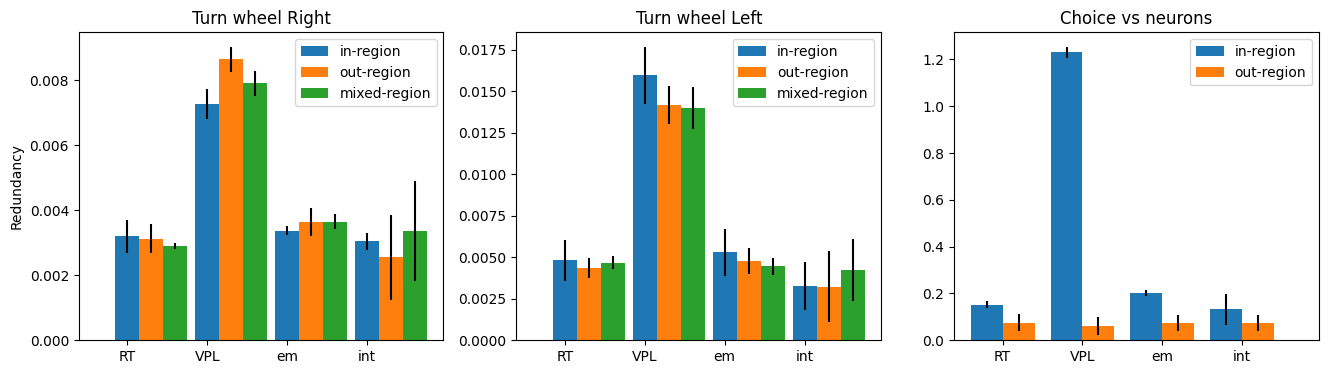

In [99]:


fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_choice_right_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_choice_right_inregion[:,3],width=0.3, yerr=inregion_std_choice_right[:,3], label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_choice_right_outregion[:,3],width=0.3, yerr=outregion_std_choice_right[:,3], label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_choice_right_mixedregion[:,3],width=0.3, yerr=mixedregion_std_choice_right[:,3], label='mixed-region')

ax[1].bar(np.arange(regions), mean_choice_left_inregion[:,3],width=0.3, yerr=inregion_std_choice_left[:,3], label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_choice_left_outregion[:,3],width=0.3, yerr=outregion_std_choice_left[:,3], label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_choice_left_mixedregion[:,3],width=0.3, yerr=mixedregion_std_choice_left[:,3], label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_choice_decoding_inregion[:,3], width=0.4, yerr=inregion_std_choice_decoding[:,3],label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_choice_decoding_outregion[:,3], width=0.4, yerr=outregion_std_choice_decoding[:,3], label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()


ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_choice))

ax[0].set_title('Turn wheel Right')
ax[1].set_title('Turn wheel Left')
ax[2].set_title('Choice vs neurons')
ax[0].set_ylabel('Redundancy')

Text(0, 0.5, 'Synergy')

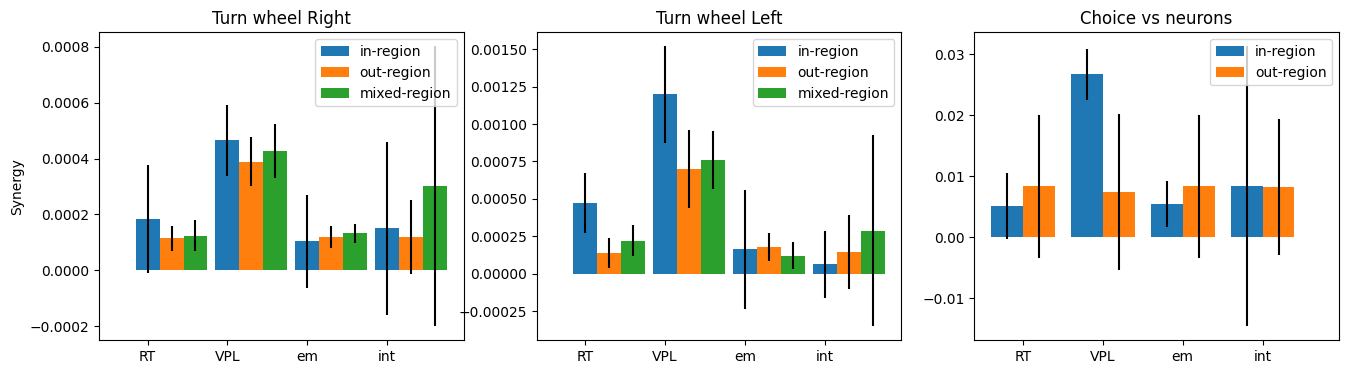

In [112]:


fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_choice_right_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_choice_right_inregion[:,2]/2,width=0.3, yerr=inregion_std_choice_right[:,2]/2, label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_choice_right_outregion[:,2]/2,width=0.3, yerr=outregion_std_choice_right[:,2]/2, label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_choice_right_mixedregion[:,2]/2,width=0.3, yerr=mixedregion_std_choice_right[:,2]/2, label='mixed-region')

ax[1].bar(np.arange(regions), mean_choice_left_inregion[:,2]/2,width=0.3, yerr=inregion_std_choice_left[:,2]/2, label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_choice_left_outregion[:,2]/2,width=0.3, yerr=outregion_std_choice_left[:,2]/2, label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_choice_left_mixedregion[:,2]/2,width=0.3, yerr=mixedregion_std_choice_left[:,2]/2, label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_choice_decoding_inregion[:,2]/2, width=0.4, yerr=inregion_std_choice_decoding[:,2]/2,label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_choice_decoding_outregion[:,2]/2, width=0.4, yerr=outregion_std_choice_decoding[:,2]/2, label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()


ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_choice))

ax[0].set_title('Turn wheel Right')
ax[1].set_title('Turn wheel Left')
ax[2].set_title('Choice vs neurons')
ax[0].set_ylabel('Synergy')

In [100]:
## same for stimulus
mean_stim_right_inregion = inregion_pid_stim_right/inregion_count_stim_right
mean_stim_right_outregion = outregion_pid_stim_right/outregion_count_stim_right
mean_stim_right_mixedregion = mixedregion_pid_stim_right/mixedregion_count_stim_right


mean_stim_left_inregion = inregion_pid_stim_left/inregion_count_stim_left
mean_stim_left_outregion = outregion_pid_stim_left/outregion_count_stim_left
mean_stim_left_mixedregion = mixedregion_pid_stim_left/mixedregion_count_stim_left

mean_stim_decoding_inregion = inregion_pid_stim_decoding/inregion_count_stim_decoding
mean_stim_decoding_outregion = outregion_pid_stim_decoding/outregion_count_stim_decoding

Text(0, 0.5, 'Redundancy')

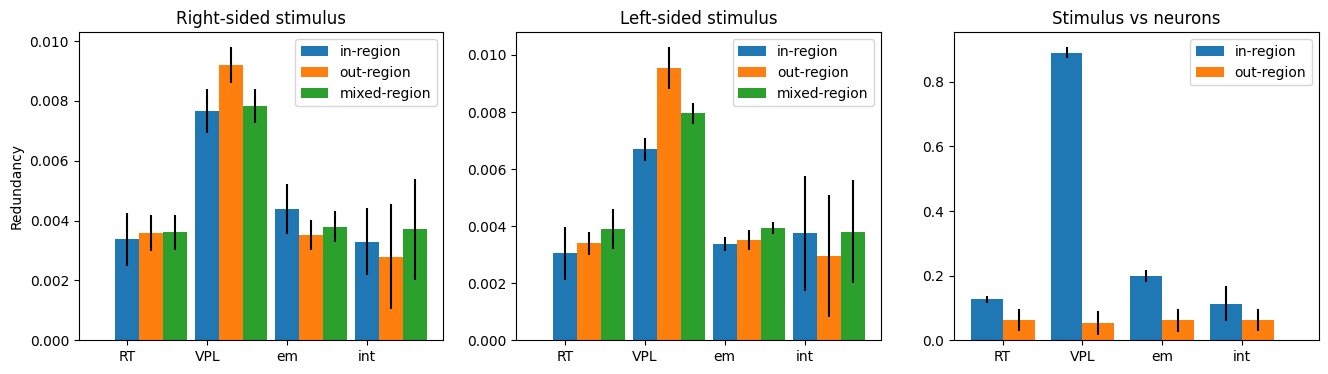

In [101]:
fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_stim_right_inregion[:,3],width=0.3, yerr=inregion_std_stim_right[:,3], label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_stim_right_outregion[:,3],width=0.3, yerr=outregion_std_stim_right[:,3], label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_stim_right_mixedregion[:,3],width=0.3, yerr=mixedregion_std_stim_right[:,3], label='mixed-region')

ax[1].bar(np.arange(regions), mean_stim_left_inregion[:,3],width=0.3, yerr=inregion_std_stim_left[:,3], label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_stim_left_outregion[:,3],width=0.3, yerr=outregion_std_stim_left[:,3], label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_stim_left_mixedregion[:,3],width=0.3, yerr=mixedregion_std_stim_left[:,3], label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_stim_decoding_inregion[:,3], width=0.4, yerr=inregion_std_stim_decoding[:,3],label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_stim_decoding_outregion[:,3], width=0.4, yerr=outregion_std_stim_decoding[:,3], label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()

neuron_location_stim
ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_stim))

ax[0].set_title('Right-sided stimulus')
ax[1].set_title('Left-sided stimulus')
ax[2].set_title('Stimulus vs neurons')
ax[0].set_ylabel('Redundancy')

Text(0, 0.5, 'Synergy')

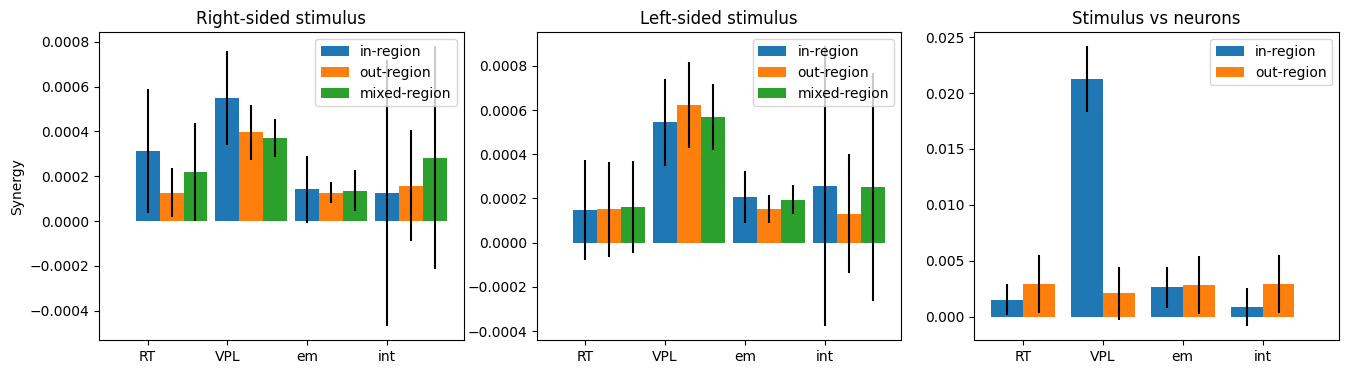

In [113]:


fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_stim_right_inregion[:,2]/2,width=0.3, yerr=inregion_std_stim_right[:,2]/2, label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_stim_right_outregion[:,2]/2,width=0.3, yerr=outregion_std_stim_right[:,2]/2, label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_stim_right_mixedregion[:,2]/2,width=0.3, yerr=mixedregion_std_stim_right[:,2]/2, label='mixed-region')

ax[1].bar(np.arange(regions), mean_stim_left_inregion[:,2]/2,width=0.3, yerr=inregion_std_stim_left[:,2]/2, label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_stim_left_outregion[:,2]/2,width=0.3, yerr=outregion_std_stim_left[:,2]/2, label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_stim_left_mixedregion[:,2]/2,width=0.3, yerr=mixedregion_std_stim_left[:,2]/2, label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_stim_decoding_inregion[:,2]/2, width=0.4, yerr=inregion_std_stim_decoding[:,2]/2,label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_stim_decoding_outregion[:,2]/2, width=0.4, yerr=outregion_std_stim_decoding[:,2]/2, label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()


ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_stim))

ax[0].set_title('Right-sided stimulus')
ax[1].set_title('Left-sided stimulus')
ax[2].set_title('Stimulus vs neurons')
ax[0].set_ylabel('Synergy')

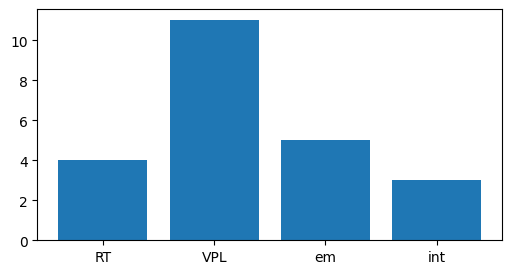

In [109]:
regions, count = np.unique(neuron_location_choice, return_counts=True)
fig,ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(len(regions)), count)
ax.set_xticks(np.arange(len(regions)),regions)

In [114]:
### now for feedback period

correct_feedback = trials[mask].feedbackType == 1
incorrect_feedback = trials[mask].feedbackType == -1
feedback_trials = correct_feedback | incorrect_feedback

time_window_feedback = [0.0, 0.2]
events_feedback = trials[mask][feedback_trials].feedback_times
events_feedback_tw = np.array(
    [events_feedback + time_window_feedback[0], events_feedback + time_window_feedback[1]]
).T

## for correct and incorrect feedback

spike_count_feedback, cluster_id = get_spike_counts_in_bins(
    spikes_insertion_one["times"], spikes_insertion_one["clusters"], events_feedback_tw
)

# also, now for single cells, to be used for a lag based analysis
p_eths, bin_counts_feedback = singlecell.calculate_peths(
    spikes_insertion_one["times"],
    spikes_insertion_one["clusters"],
    cluster_id,
    align_times=events_feedback,
    smoothing=False,
    bin_size=0.01,
    pre_time=0.0,
    post_time=0.2,
)


correct_feedback_spike_data = np.asarray(
    bin_counts_feedback[correct_feedback, :, :], dtype=np.int32
)
incorrect_feedback_spike_data = np.asarray(
    bin_counts_feedback[incorrect_feedback, :, :], dtype=np.int32
)

spike_count_feedback_data = spike_count_feedback[:, feedback_trials]
feedback_side = correct_feedback * 1 + incorrect_feedback * -1

# remove zeros
feedback_side = feedback_side[feedback_side != 0].values

important_neurons_feedback = find_important_neurons(spike_count_feedback_data)

data_correct_feedback = Data(
    correct_feedback_spike_data[:, important_neurons_feedback, :], dim_order="rps", normalise=False
)
data_incorrect_feedback = Data(
    incorrect_feedback_spike_data[:, important_neurons_feedback, :],
    dim_order="rps",
    normalise=False,
)
sources_feedback = generate_sources(np.arange(len(important_neurons_feedback)))
targets_feedback = np.arange(len(important_neurons_feedback), dtype=np.int32)

neuron_location_feedback = clusters_insertion_one["acronym"][important_neurons_feedback].values


# regions = np.unique(neuron_location_feedback)


groupings_singlecell_feedback = generate_groupings(
    neuron_location_feedback, important_neurons_feedback
)
pid_storage_correct_feedback = computePID(
    sources_feedback, targets_feedback, data=data_correct_feedback
)
pid_storage_incorrect_feedback = computePID(
    sources_feedback, targets_feedback, data=data_incorrect_feedback
)


spike_count_feedback_data_important = spike_count_feedback_data[important_neurons_feedback, :]
decoding_array_feedback = build_decoding_array(feedback_side, spike_count_feedback_data_important)

# transpose so that it is neurons x trials x spike_counts
# multivariate cause why not
# target is variable 0
decoding_array_feedback = np.transpose(decoding_array_feedback, (0, 2, 1))

PID_feedback_decoding = compute_pid_neurons(decoding_array_feedback)

_, Rdecoding_feedback = generate_groupings_decoding(
    neuron_location_feedback, important_neurons_feedback
)

(
    inregion_pid_feedback_decoding,
    inregion_count_feedback_decoding,
    outregion_pid_feedback_decoding,
    outregion_count_feedback_decoding,
    inregion_std_feedback_decoding,
    outregion_std_feedback_decoding,
) = group_decoding_results(PID_feedback_decoding, Rdecoding_feedback, neuron_location_feedback)


(
    inregion_pid_feedback_left,
    inregion_count_feedback_left,
    inregion_std_feedback_left,
    outregion_pid_feedback_left,
    outregion_count_feedback_left,
    outregion_std_feedback_left,
    mixedregion_pid_feedback_left,
    mixedregion_count_feedback_left,
    mixedregion_std_feedback_left,
) = combine_multidimensional_pid(
    pid_storage_correct_feedback, groupings_singlecell_feedback, neuron_location_feedback
)


(
    inregion_pid_feedback_incorrect,
    inregion_count_feedback_incorrect,
    inregion_std_feedback_incorrect,
    outregion_pid_feedback_incorrect,
    outregion_count_feedback_incorrect,
    outregion_std_feedback_incorrect,
    mixedregion_pid_feedback_incorrect,
    mixedregion_count_feedback_incorrect,
    mixedregion_std_feedback_incorrect,
) = combine_multidimensional_pid(
    pid_storage_incorrect_feedback, groupings_singlecell_feedback, neuron_location_feedback
)

Adding data with properties: 30 processes, 20 samples, 370 replications
overwriting existing data
Adding data with properties: 30 processes, 20 samples, 122 replications
overwriting existing data


0it [00:00, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

...

  0%|          | 0/406 [00:00<?, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

  0%|          | 0/406 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
## same for feedbackulus
mean_feedback_correct_inregion = inregion_pid_feedback_left/inregion_count_feedback_left
mean_feedback_correct_outregion = outregion_pid_feedback_left/outregion_count_feedback_left
mean_feedback_correct_mixedregion = mixedregion_pid_feedback_left/mixedregion_count_feedback_left


mean_feedback_incorrect_inregion = inregion_pid_feedback_incorrect/inregion_count_feedback_incorrect
mean_feedback_incorrect_outregion = outregion_pid_feedback_incorrect/outregion_count_feedback_incorrect
mean_feedback_incorrect_mixedregion = mixedregion_pid_feedback_incorrect/mixedregion_count_feedback_incorrect

mean_feedback_decoding_inregion = inregion_pid_feedback_decoding/inregion_count_feedback_decoding
mean_feedback_decoding_outregion = outregion_pid_feedback_decoding/outregion_count_feedback_decoding

In [ ]:
fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_feedback_correct_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_feedback_correct_inregion[:,3],width=0.3, yerr=inregion_std_feedback_left[:,3], label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_feedback_correct_outregion[:,3],width=0.3, yerr=outregion_std_feedback_left[:,3], label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_feedback_correct_mixedregion[:,3],width=0.3, yerr=mixedregion_std_feedback_left[:,3], label='mixed-region')

ax[1].bar(np.arange(regions), mean_feedback_incorrect_inregion[:,3],width=0.3, yerr=inregion_std_feedback_incorrect[:,3], label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_feedback_incorrect_outregion[:,3],width=0.3, yerr=outregion_std_feedback_incorrect[:,3], label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_feedback_incorrect_mixedregion[:,3],width=0.3, yerr=mixedregion_std_feedback_incorrect[:,3], label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_feedback_decoding_inregion[:,3], width=0.4, yerr=inregion_std_feedback_decoding[:,3],label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_feedback_decoding_outregion[:,3], width=0.4, yerr=outregion_std_feedback_decoding[:,3], label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_feedback))

ax[0].set_title('Correct feedback')
ax[1].set_title('Incorrect feedback')
ax[2].set_title('Feedback in neurons')
ax[0].set_ylabel('Redundancy')

In [ ]:
regions, count = np.unique(neuron_location_feedback, return_counts=True)
fig,ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(len(regions)), count)
ax.set_xticks(np.arange(len(regions)),regions)

In [117]:
clusters_insertion_one.acronym.unique()

array(['MEA', 'opt', 'int', 'em', 'VPL', 'RT'], dtype=object)

In [119]:
clusters_insertion_one[clusters_insertion_one.acronym=='em']

,channels,depths,uuids,cluster_id,amp_max,amp_min,amp_median,amp_std_dB,contamination,contamination_alt,...,label,x,y,z,acronym,atlas_id,axial_um,lateral_um,labels,rawInd
17,219,2200.0,4021fdf5-e319-4469-b465-f37cda01a135,189,0.000333,0.000087,0.000146,1.299445,0.076149,0.067176,...,1.0,-0.002388,-0.001458,-0.004098,em,1092,2200.0,27.0,1,219
18,223,2240.0,8bcebd35-3699-4b33-9479-1c420916558d,201,0.000422,0.000106,0.000170,1.620008,0.154867,0.129474,...,1.0,-0.002388,-0.001452,-0.004063,em,1092,2240.0,27.0,1,223
19,223,2240.0,2ab3ebce-0e32-4ba5-b859-be8b20a2e070,214,0.000640,0.000185,0.000286,1.194204,0.185896,0.150975,...,1.0,-0.002388,-0.001452,-0.004063,em,1092,2240.0,27.0,1,223
20,223,2240.0,799d6fe6-b4a2-4594-8d23-55fc5c5e1749,216,0.000776,0.000202,0.000325,1.172888,0.048924,0.043639,...,1.0,-0.002388,-0.001452,-0.004063,em,1092,2240.0,27.0,1,223
21,223,2240.0,521d1eae-5f30-4e3a-b2b8-1629ba5113a5,219,0.000366,0.000102,0.000166,1.348260,0.093602,0.080794,...,1.0,-0.002388,-0.001452,-0.004063,em,1092,2240.0,27.0,1,223
49,295,2960.0,fec9cee9-ce46-49a8-9e92-8b6852ff7e5b,446,0.000390,0.000136,0.000211,1.143659,0.214649,0.171035,...,1.0,-0.002327,-0.001306,-0.003464,em,1092,2960.0,27.0,0,295
60,219,2200.0,b082a55f-5349-4417-a2c3-7aa4a96fd044,610,0.000418,0.000167,0.000250,0.941430,0.027238,0.024806,...,1.0,-0.002388,-0.001458,-0.004098,em,1092,2200.0,27.0,1,219


In [120]:
ba = AllenAtlas()

In [124]:
ba.get_labels([-0.002388,-0.001458,-0.004098])

1092

In [127]:
from iblatlas.regions import BrainRegions

In [129]:
br = BrainRegions()

In [135]:
br.acronym2acronym('em', mapping='Cosmos')

array(['root'], dtype=object)

In [134]:
br.acronym2acronym('int', mapping='Cosmos')

array(['root'], dtype=object)

NameError: name 'mean_feedback_correct_inregion' is not defined

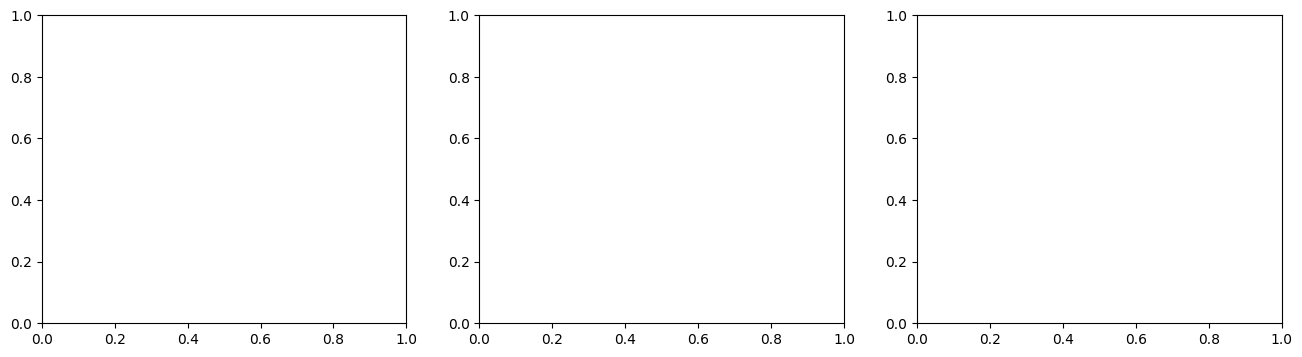

In [136]:
fig, ax = plt.subplots(figsize=(16,4),ncols=3, sharex=True)
regions = mean_feedback_correct_inregion.shape[0]

ax[0].bar(np.arange(regions), mean_feedback_correct_inregion[:,3],width=0.3, yerr=inregion_std_feedback_left[:,3], label='in-region')
ax[0].bar(np.arange(regions)+0.3, mean_feedback_correct_outregion[:,3],width=0.3, yerr=outregion_std_feedback_left[:,3], label='out-region')
ax[0].bar(np.arange(regions)+0.6, mean_feedback_correct_mixedregion[:,3],width=0.3, yerr=mixedregion_std_feedback_left[:,3], label='mixed-region')

ax[1].bar(np.arange(regions), mean_feedback_incorrect_inregion[:,3],width=0.3, yerr=inregion_std_feedback_incorrect[:,3], label='in-region')
ax[1].bar(np.arange(regions)+0.3, mean_feedback_incorrect_outregion[:,3],width=0.3, yerr=outregion_std_feedback_incorrect[:,3], label='out-region')
ax[1].bar(np.arange(regions)+0.6, mean_feedback_incorrect_mixedregion[:,3],width=0.3, yerr=mixedregion_std_feedback_incorrect[:,3], label='mixed-region')

ax[2].bar(np.arange(regions)-0.2, mean_feedback_decoding_inregion[:,3], width=0.4, yerr=inregion_std_feedback_decoding[:,3],label='in-region')
ax[2].bar(np.arange(regions)+0.2, mean_feedback_decoding_outregion[:,3], width=0.4, yerr=outregion_std_feedback_decoding[:,3], label='out-region')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xticks(np.arange(regions),np.unique(neuron_location_feedback))

ax[0].set_title('Correct feedback')
ax[1].set_title('Incorrect feedback')
ax[2].set_title('Feedback in neurons')
ax[0].set_ylabel('Redundancy')

In [8]:
# try out merged probes, and check if it is different from my code
import pandas as pd

In [9]:
eids_df = pd.read_csv('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\eids_to_analyse.csv')
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
eids = eids_df.eid

In [10]:
eid = eids[0]

In [11]:
eid

'b52182e7-39f6-4914-9717-136db589706e'

In [12]:
pids, probes = one.eid2pid(eid) # get pids

In [18]:
probes

['probe00', 'probe01']

In [17]:
from iblutil.numerical import bincount2D

In [16]:
def get_spike_data_per_trial(times, clusters, intervals, binsize, n_bins=None):
    """Select spiking data for specified interval on each trial.

    Parameters
    ----------
    times : array-like
        time in seconds for each spike
    clusters : array-like
        cluster id for each spike
    intervals : np.array
        shape (n_trials, 2) where columns indicate interval onset/offset (seconds)
    binsize : float
        width of each bin in seconds
    n_bins : int
        number of bins; should be computable from intervals and binsize, but there are occasional rounding errors

    Returns
    -------
    tuple
        - (list): time in seconds for each trial; timepoints refer to the start/left edge of a bin
        - (list): data for each trial of shape (n_clusters, n_bins)

    """

    interval_begs = intervals[:, 0]
    interval_ends = intervals[:, 1]
    interval_len = interval_ends - interval_begs
    n_trials = intervals.shape[0]

    # np.ceil because we want to make sure our bins contain all data
    if n_bins is None:
        n_bins = int(np.median(np.ceil(interval_len / binsize).astype('int')))

    cluster_ids = np.unique(clusters)
    n_clusters_in_region = len(cluster_ids)

    binned_spikes = np.zeros((n_trials, n_clusters_in_region, n_bins))
    spike_times_list = []
    for tr, (t_beg, t_end) in enumerate(zip(interval_begs, interval_ends)):
        # just get spikes for this region/trial
        idxs_t = (times >= t_beg) & (times < t_end)
        times_curr = times[idxs_t]
        clust_curr = clusters[idxs_t]
        if times_curr.shape[0] == 0:
            # no spikes in this trial
            binned_spikes_tmp = np.zeros((n_clusters_in_region, n_bins))
            if np.isnan(t_beg) or np.isnan(t_end):
                t_idxs = np.nan * np.ones(n_bins)
            else:
                t_idxs = np.arange(t_beg, t_end + binsize / 2, binsize)
            idxs_tmp = np.arange(n_clusters_in_region)
        else:
            # bin spikes
            binned_spikes_tmp, t_idxs, cluster_idxs = bincount2D(
                times_curr, clust_curr, xbin=binsize, xlim=[t_beg, t_end])
            # find indices of clusters that returned spikes for this trial
            _, idxs_tmp, _ = np.intersect1d(cluster_ids, cluster_idxs, return_indices=True)

        # update data block
        binned_spikes[tr, idxs_tmp, :] += binned_spikes_tmp[:, :n_bins]
        spike_times_list.append(t_idxs[:n_bins])

    return binned_spikes, spike_times_list

def build_lagged_predictor_matrix(array, n_lags, return_valid=True):
    """Build predictor matrix with time-lagged datapoints.

    Parameters
    ----------
    array : np.ndarray
        shape (n_time, n_clusters)
    n_lags : int
        number of lagged timepoints (includes zero lag)
    return_valid : bool, optional
        True to crop first n_lags rows, False to leave all

    Returns
    -------
    np.ndarray
        shape (n_time - n_lags, n_clusters * (n_lags + 1)) if return_valid==True
        shape (n_time, n_clusters * (n_lags + 1)) if return_valid==False

    """
    if n_lags < 0:
        raise ValueError('`n_lags` must be >=0, not {}'.format(n_lags))
    mat = np.hstack([np.roll(array, i, axis=0) for i in range(n_lags + 1)])
    if return_valid:
        mat = mat[n_lags:]
    return mat




In [26]:
def prepare_ephys(
        one, session_id, probe_name, regions, intervals, binsize=None, n_bins_lag=None, n_bins=None, qc=1, min_units=10,
        stage_only=False,
):

    # Load spikes and clusters and potentially merge probes
    if isinstance(probe_name, list) and len(probe_name) > 1:
        to_merge = [load_good_units(one, pid=None, eid=session_id, qc=qc, pname=probe_name)
                    for probe_name in probe_name]
        spikes, clusters = merge_probes([spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge])
    else:
        spikes, clusters = load_good_units(one, pid=None, eid=session_id, qc=qc, pname=probe_name)

    # This allows us to just stage the data without running the analysis, we can then switch ONE in local mode
    if stage_only:
        return None, None, None, None

    # Prepare list of brain regions
    brainreg = BrainRegions()
    beryl_regions = brainreg.acronym2acronym(clusters['acronym'], mapping="Beryl")
    if isinstance(regions, str):
        if regions == 'single_regions':  # if single_regions, make a list of lists to decode every region separately
            regions = [[b] for b in np.unique(beryl_regions) if b not in ['root', 'void']]
        elif regions == 'all_regions':  # if all regions make a list of a single list to decode all regions together
            regions = [[b for b in np.unique(beryl_regions) if b not in ['root', 'void']]]
        else:
            regions = [regions]  # if one region is given, put it into a list
    elif isinstance(regions, list):
        pass

    binned_spikes = []
    actual_regions = []
    n_units = []
    cluster_uuids_list = []
    for region in regions:
        # find all clusters in region (where region can be a list of regions)
        region_mask = np.isin(beryl_regions, region)
        if sum(region_mask) < min_units:
            print(f"{'_'.join(region)} below min units threshold ({min_units}) : {sum(region_mask)}, not decoding")
        else:
            # find all spikes in those clusters
            spike_mask = np.isin(spikes['clusters'], clusters[region_mask].index)
            times_masked = spikes['times'][spike_mask]
            clusters_masked = spikes['clusters'][spike_mask]
            # record cluster uuids
            idxs_used = np.unique(clusters_masked)
            clusters_uuids = list(clusters.iloc[idxs_used]['uuids'])
            # bin spikes from those clusters
            if binsize is None:
                binned, _ = get_spike_counts_in_bins(
                    spike_times=times_masked, spike_clusters=clusters_masked, intervals=intervals)
                binned = binned.T
            else:
                # TODO: integrate this into `get_spike_counts_in_bins`
                # update "intervals" to include more data to facilitate the lags
                intervals_for_lags = np.copy(intervals)
                intervals_for_lags[:, 0] = intervals_for_lags[:, 0] - n_bins_lag * binsize
                # count spikes in multiple bins per interval
                binned_2d, _ = get_spike_data_per_trial(
                    times=times_masked, clusters=clusters_masked, intervals=intervals_for_lags,
                    binsize=binsize, n_bins=n_bins + n_bins_lag,
                )
                # include lagged timepoints for each sample
                binned = [build_lagged_predictor_matrix(b.T, n_bins_lag) for b in binned_2d]

            binned_spikes.append(binned)
            actual_regions.append(region)
            n_units.append(sum(region_mask))
            cluster_uuids_list.append(clusters_uuids)

    return binned_spikes, actual_regions, n_units, cluster_uuids_list

In [27]:
import numpy as np
from iblatlas.atlas import BrainRegions

In [28]:
sl = SessionLoader(one, eid=eid)
sl.load_trials()
trials_df, trials_mask = load_trials_and_mask(one=one, eid=eid, sess_loader=sl, min_rt=0.08, max_rt=2.0, nan_exclude='default', exclude_nochoice=True)
align_event = 'stimOn_times'
time_window_stim = [0.0, 0.1]
intervals = np.vstack([sl.trials[align_event] + time_window_stim[0], sl.trials[align_event] + time_window_stim[1]]).T

In [41]:
binned_spikes, actual_regions, n_units, cluster_uuids_list = prepare_ephys(one, session_id=eid, probe_name=probes, regions='single_regions', intervals=intervals
                                                                           ,binsize=None, min_units=5)

In [42]:
# now for my code


In [51]:
def gather_data_all(trials_df, spikes_probe0, spikes_probe1, time_window=[0.0,0.1]):
    """
    Gather data around choice interval from multiple probes

    Args:
        trials_df (pandas.df): Trial dataframe
        spikes_probe0 (dict): Neural data from probe
        spikes_probe1 (dict): Neural data from probe
        time_window (list, optional): Time window in which to pool the data. Defaults to [0,0.1].

    Returns:
        spike_count_choice_probe0 (np.array): Spike counts for probe 0, neurons x trials
        spike_count_choice_probe1 (np.array): Spike counts for probe 1, neurons x trials
        cluster_id_probe0 (np.array) : Neural cluster ids for probe 0
        cluster_id_probe1 (np.array) : Neural cluster ids for probe 1
        decoding_variable (np.array) : Choice direction
    """
    
    align_event = 'stimOn_times'
    events_choice_tw = np.vstack([trials_df[align_event] + time_window[0], trials_df[align_event] + time_window[1]]).T
    # Neurons x Trials
    spike_count_choice_probe0, cluster_id_probe0 = get_spike_counts_in_bins(spikes_probe0["times"], spikes_probe0["clusters"], events_choice_tw)
    spike_count_choice_probe1, cluster_id_probe1 = get_spike_counts_in_bins(spikes_probe1["times"], spikes_probe1["clusters"], events_choice_tw)

    # for now, we don't use the single-cell peths

    return spike_count_choice_probe0, spike_count_choice_probe1, cluster_id_probe0, cluster_id_probe1, trials_df['probabilityLeft']

def cleanup_data(neural_data, regions):
    """
    Throw away rows with root, void and other undesirable regions

    Args:
        neural_data (np.array): neurons x trials
        regions (np.array): acronym for neurons

    Returns:
        neural_data (np.array) : neurons x trials, cleaned 
        regions (np.array) : acronym for cleaned up neurons

    """

    # if region not in region_info.csv, throw away
    csv_location = Path('D:/personal/phD/code/information-decomposition/ibl-partial-info-decomp/data/external/region_info.csv')
    nice_regions = pd.read_csv(csv_location)['Beryl']
    bad_indices = np.isin(regions, nice_regions)==False
    print(f"Neurons thrown away: {regions[bad_indices]}")

    #TODO: maybe throw away regions that don't have enough neurons

    neural_data = neural_data[~bad_indices, :]
    regions = regions[~bad_indices]

    return np.asarray(neural_data, dtype=np.int32), regions

def combine_probes(spike_count_stim_probe0, spike_count_stim_probe1, regions_probe0, regions_probe1, aggregate=False, average=False, discretize=False, method='all'):
    """
    Combine probes from same session

    Args:
        spike_count_stim_probe0 (dict): Spike data from probe 0
        spike_count_stim_probe1 (dict): Spike data from probe 1
        regions_probe0 (np.array): Regional acronyms from probe 0
        regions_probe1 (np.array): Regional acronyms from probe 1
        aggregate (bool, optional): Aggreate regions or not. Defaults to False.

    Returns:
        neural_data (np.array) neurons x trials
        regions (np.array): neuron regions
    """

    # best place to run filter to see if there are enough neurons from each region
    MINIMUM_NUMBER = 5

    if aggregate:
        # combine neurons from multiple regions into one big chunk
        # spike_count_probe is neurons x trials
        aggregate_neural_data = np.vstack([spike_count_stim_probe0, spike_count_stim_probe1])
        aggregate_regions = np.concatenate([regions_probe0, regions_probe1])

        # now run aggregation
        aggregate_neural_data, aggregate_regions = aggregated_regions_time_intervals(aggregate_neural_data.T, aggregate_regions, average=average) # because the function expects trials x neurons
        # now we clean up the data?
        neural_data, regions = cleanup_data(aggregate_neural_data.T, aggregate_regions)
    else:
        neural_data_probe0, regions_probe0 = cleanup_data(spike_count_stim_probe0, regions_probe0)        
        neural_data_probe1, regions_probe1 = cleanup_data(spike_count_stim_probe1, regions_probe1)
                                                
        # concatenate regions and neural data
        neural_data = np.vstack([neural_data_probe0, neural_data_probe1])
        regions = np.concatenate([regions_probe0, regions_probe1])

        ## get regions and count
        neural_data, regions = maintain_neural_count(neural_data, regions)



    # plot_neurons(neural_data, regions)
    return neural_data, regions

def maintain_neural_count(neural_data, regions, minimum_number = 5):
    """
    Ensure that the total number of neurons in each region is greater than a specified minimum number

    Args:
        neural_data (np.array): neurons x trials
        regions (np.array): name of regions for each neuron
        minimum_number (int) : minimum number of neurons in each region required to pass, defaults to 5
    """

    
    unique_regions, neuron_per_region = np.unique(regions, return_counts= True)
    valid_regions_idx = np.argwhere(neuron_per_region>minimum_number)
    valid_regions = unique_regions[valid_regions_idx].reshape(-1,)

    # now to get only data from valid regions
    region_idx = np.argwhere(np.isin(regions, valid_regions)).reshape(-1,)
    neural_data = neural_data[region_idx, :]
    regions = regions[region_idx].reshape(-1,)

    return neural_data, regions


In [53]:

spikes_probe0, clusters_probe0 = load_good_units(one, pids[0], probes[0])
spikes_probe1, clusters_probe1 = load_good_units(one, pids[1], probes[1])

# don't combine until we send it to the pid calculations
brainreg = BrainRegions()    
clusters_probe0['Beryl'] = brainreg.acronym2acronym(clusters_probe0.acronym.values, mapping='Beryl')
clusters_probe1['Beryl'] = brainreg.acronym2acronym(clusters_probe1.acronym.values, mapping='Beryl')

(
    spike_count_stim_probe0, 
    spike_count_stim_probe1, 
    cluster_id_probe0, 
    cluster_id_probe1, 
    decoding_variable
) = gather_data_all(trials_df, spikes_probe0, spikes_probe1)

regions_probe0 = clusters_probe0['Beryl'][cluster_id_probe0].to_numpy()
regions_probe1 = clusters_probe1['Beryl'][cluster_id_probe1].to_numpy()

# drop unwanted neurons
neural_data, regions = combine_probes(spike_count_stim_probe0, spike_count_stim_probe1, regions_probe0, regions_probe1)

Neurons thrown away: ['root' 'root' 'root']
Neurons thrown away: []


In [57]:
np.unique(regions, return_counts=True)

(array(['APN', 'CA1', 'DG', 'VISam', 'VISpm'], dtype=object),
 array([15, 26,  9, 21, 26], dtype=int64))

In [58]:
actual_regions, n_units


([['APN'], ['CA1'], ['CA3'], ['DG'], ['MRN'], ['VISam'], ['VISpm']],
 [15, 26, 5, 9, 5, 21, 26])

In [63]:
idx = np.argwhere(regions=='APN').reshape(-1,)

In [66]:
APN = neural_data[idx, :]

In [67]:
APN.shape

(15, 700)

In [68]:
binned_spikes[0].shape

(700, 15)

In [69]:
APN = APN.T

In [71]:
APN.shape

(700, 15)

In [72]:
binned_spikes[0].shape

(700, 15)

In [74]:
binned_spikes[0][0,:]

array([4, 0, 2, 0, 2, 2, 1, 4, 5, 1, 0, 1, 0, 0, 1], dtype=uint32)

In [75]:
APN[0,:]

array([4, 0, 2, 0, 2, 2, 1, 4, 5, 1, 0, 1, 0, 0, 1])